# Archetype 5 — Base + Electric Vehicle (EV)

## Purpose

Computes the annual TCoE for **Archetype 5: Base + EV (50 kWh / 11 kW)** across 3 strategies x 7 DSOs -> **21 runs**.

The EV can shift its charging window within the hours it is plugged in at home, while respecting a minimum departure SoC. This makes EVs a strong §14a-eligible flexible load: large per-event energy blocks that can easily be shifted from peak (HT) to off-peak (NT) windows.

| Strategy | Flexible resource | Signal |
|---|---|---|
| **no_flex** | None — greedy charge as soon as plugged in | none |
| **dt_flex** | LP shifts EV charging over the year | spot (ct/kWh) on total site import |
| **tcoe_flex** | LP per DSO x §14a option — shifts EV charging | spot + DSO EV-rate + levies (ct/kWh) |

**§14a module optimisation:** For `tcoe_flex`, the LP is solved under each of the three §14a options (opt1 / opt2 / opt1+3); the option yielding the lowest billed annual cost is retained.

## Input files (`inputs/`)

| File | Content |
|---|---|
| `base_demand_h25_4500kwh_2026_15min.csv` | BDEW H25 base demand (kWh/slot) |
| `ev_profile_representative_50kwh_11kw_2026_15min.csv` | EV availability + driving demand profile (Kassel 2026) |
| `ev_parameters_representative_50kwh_11kw_2026.csv` | Battery capacity, power, efficiency — frozen optimisation parameters |
| `spot_prices_de_lu_2025_15min.csv` | Day-ahead spot price (ct/kWh) |
| `dso_tariffs_residential_2026.csv` | Residential base tariffs + §14a module parameters |
| `dso_mod3_timebands_2026.csv` | §14a Modul 3 HT/NT/ST timeband rules per DSO |
| `residential_taxes_2026.csv` | German levies (ct/kWh, pre-VAT) |

## Output (`outputs/`)

`results_base_ev_2026.csv` — 21 rows x cost-component columns including `billing_14a_option` and `optimized_14a_option`.

## Billing convention

Pre-VAT levy bundle in net subtotal; single 19% VAT on full subtotal. `cost_smart_operating_net_eur = 100 EUR/year`. §14a Modul 1 rebate (annual EUR) enters the DSO volumetric component for opt1 and opt1+3.

## Solver

Gurobi via PuLP. LP (continuous, no binary variables) at 15-min resolution (T = 35,040). One LP per strategy x DSO x §14a option for `tcoe_flex` (max 7 x 3 = 21 LP solves).

## Thesis reference

Chapter 5, Section 5.1 — Results: Archetype 5 (Base + EV)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -- thesis figure rc (shared across notebooks) --
plt.rcParams.update({
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

import matplotlib.dates as mdates
import pulp
from pathlib import Path

os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/gurobi.lic')

def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f'Repo root (containing {marker}) not found.')

REPO_ROOT = find_repo_root()
INPUTS    = REPO_ROOT / 'inputs'
OUTPUTS   = REPO_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f'Repo root : {REPO_ROOT}')


Repo root : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load inputs and EV parameters

In [2]:
# Base demand (H25)
base_demand = pd.read_csv(INPUTS / 'base_demand_h25_4500kwh_2026_15min.csv',
                          parse_dates=['timestamp'])

# EV profile — uses 'local_time' as datetime column; rename for consistency
ev_profile = pd.read_csv(INPUTS / 'ev_profile_representative_50kwh_11kw_2026_15min.csv',
                         parse_dates=['local_time'])
ev_profile = ev_profile.rename(columns={'local_time': 'timestamp'})

# Spot prices
spot = pd.read_csv(INPUTS / 'spot_prices_de_lu_2025_15min.csv',
                   parse_dates=['timestamp'])

# Merge to single working DataFrame
df = (base_demand
      .merge(ev_profile[['timestamp', 'f_avail', 'E_EV_demand_kWh']], on='timestamp')
      .merge(spot[['timestamp', 'price_ct_kWh']], on='timestamp'))
df['price_ct_kWh'] = df['price_ct_kWh'].ffill().bfill()
n = len(df)

# ── EV physical parameters (frozen at export time in input notebook 06) ────────
ev_params = pd.read_csv(INPUTS / 'ev_parameters_representative_50kwh_11kw_2026.csv',
                        index_col='parameter')['value']
E_EV_max    = float(ev_params['E_EV_max_kWh'])        # [kWh] usable battery capacity
P_EV_max    = float(ev_params['P_EV_max_ch_kW'])      # [kW]  max AC charging power
eta_EV      = float(ev_params['eta_EV_charge'])        # [-]   AC-DC charging efficiency
q_loss_EV   = float(ev_params['q_losses_EV'])          # [1/h] standby loss rate
E_min_dep   = float(ev_params['E_min_departure_kWh']) # [kWh] min SoC at departure
E_min_home  = float(ev_params['E_min_home_kWh'])    # [kWh] $E_{\min,\mathrm{home}}$ (min SoC while at home)

ev_p = {'E_EV_max_kWh': E_EV_max, 'P_EV_max_ch_kW': P_EV_max,
        'eta_EV_charge': eta_EV, 'q_losses_EV': q_loss_EV,
        'E_min_departure_kWh': E_min_dep, 'E_min_home_kWh': E_min_home}

# ── Levies and tariffs ──────────────────────────────────────────────────────────
taxes       = pd.read_csv(INPUTS / 'residential_taxes_2026.csv')
TAX_PRE_VAT = float(taxes.loc[taxes['region'] == 'DE', 'Total_no_VAT_ct_kWh'].iloc[0])
dso_tariffs = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
SMART_OP_EUR = 100.0
VAT_RATE     = 0.19

# ── Core arrays ──────────────────────────────────────────────────────────────────
dt_h      = 0.25
q_base    = df['demand_kwh'].values           # [kWh/slot] base electricity demand
spot_arr  = df['price_ct_kWh'].values         # [ct/kWh]
f_avail   = df['f_avail'].values              # [-] EV at-home indicator (0/1)
E_dem     = df['E_EV_demand_kWh'].values      # [kWh/slot] driving energy deducted from SoC

print(f'T = {n} slots  |  base: {q_base.sum():.1f} kWh/yr  |  EV driving demand: {E_dem.sum():.1f} kWh/yr')
print(f'EV params : E_max={E_EV_max} kWh, P_max={P_EV_max} kW, eta={eta_EV}, E_min_dep={E_min_dep} kWh')
print(f'Levies (pre-VAT): {TAX_PRE_VAT} ct/kWh  |  Smart op.: {SMART_OP_EUR} EUR/year')


T = 35040 slots  |  base: 4500.0 kWh/yr  |  EV driving demand: 2610.0 kWh/yr
EV params : E_max=50.0 kWh, P_max=11.0 kW, eta=0.9, E_min_dep=25.0 kWh
Levies (pre-VAT): 6.64 ct/kWh  |  Smart op.: 100.0 EUR/year


## Step 2 — §14a Modul 3 schedule

§14a EnWG entitles EV operators to reduced DSO charges in exchange for temporary curtailability. Three billing modules apply:

| Module | Mechanism | EV billing |
|---|---|---|
| **Modul 1** | EV billed at standard DSO rate + fixed annual rebate (EUR/year) | base rate + rebate |
| **Modul 2** | EV billed at a permanently reduced flat rate (ct/kWh) | reduced flat rate |
| **Modul 3** | EV billed at time-differentiated HT/NT/ST rate | timeband rate |

**Why EVs respond strongly to Modul 3:** EVs can shift multi-kWh charging blocks (up to ~11 kW x full overnight window) entirely into the cheap NT window. The NT-to-HT spread can be 10–15 ct/kWh, creating a strong overnight incentive that is absent in the flat spot signal alone.

Timeband rules are data-driven from `dso_mod3_timebands_2026.csv`.


In [3]:
MOD3_TIMEBANDS = pd.read_csv(INPUTS / 'dso_mod3_timebands_2026.csv')

def build_ev_dso_rate_mod3(ts_index, dso_name: str, dso_row) -> np.ndarray:
    """Return per-slot §14a Modul 3 DSO rate [ct/kWh] for the EV meter.

    Unassigned slots default to ST (base rate).
    """
    ht = float(dso_row['HT_ct_kWh'])
    nt = float(dso_row['NT_ct_kWh'])
    st = float(dso_row['ST_ct_kWh'])

    T   = len(ts_index)
    idx = pd.to_datetime(ts_index)

    hours  = idx.dt.hour + idx.dt.minute / 60.0
    months = idx.dt.month
    is_q1q4 = (months <= 3) | (months >= 10)
    is_q2q3 = (months >= 4) & (months <= 9)

    rates = np.full(T, st, dtype=float)

    def in_range(h, start, end):
        if start <= end:
            return (h >= start) & (h < end)
        return (h >= start) | (h < end)

    tb = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso_name]
    for band, level in [('NT', nt), ('HT', ht)]:
        for _, r in tb[tb['band'] == band].iterrows():
            qg = str(r['quarter_group'])
            if   qg == 'all':   qmask = np.ones(T, dtype=bool)
            elif qg == 'q1q4':  qmask = is_q1q4
            elif qg == 'q2q3':  qmask = is_q2q3
            else:               qmask = np.ones(T, dtype=bool)
            rates[qmask & in_range(hours, float(r['start_hour']), float(r['end_hour']))] = level

    return rates

# ── Compact schedule overview ──────────────────────────────────────────────────
def _fmt_h(h):
    m = int(round(float(h) * 60)) % 1440
    return f'{m // 60:02d}:{m % 60:02d}'

rows = []
for _, dso_row in dso_tariffs.iterrows():
    dso = str(dso_row['DSO'])
    tb  = MOD3_TIMEBANDS[MOD3_TIMEBANDS['DSO'] == dso]
    for qlab, qg in [('Q1', 'q1q4'), ('Q2', 'q2q3'), ('Q3', 'q2q3'), ('Q4', 'q1q4')]:
        tbq  = tb[(tb['quarter_group'] == 'all') | (tb['quarter_group'] == qg)]
        def wins(band):
            w = tbq[tbq['band'] == band]
            return ', '.join(f"{_fmt_h(r['start_hour'])}-{_fmt_h(r['end_hour'])}" for _, r in w.iterrows()) or '-'
        rows.append({'DSO': dso, 'Q': qlab,
                     'HT (ct/kWh)': dso_row['HT_ct_kWh'], 'HT windows': wins('HT'),
                     'NT (ct/kWh)': dso_row['NT_ct_kWh'], 'NT windows': wins('NT'),
                     'ST (ct/kWh)': dso_row['ST_ct_kWh']})
display(pd.DataFrame(rows))


,DSO,Q,HT (ct/kWh),HT windows,NT (ct/kWh),NT windows,ST (ct/kWh)
0,Westnetz,Q1,15.65,15:00-20:00,0.95,00:00-07:00,9.53
1,Westnetz,Q2,15.65,15:00-20:00,0.95,00:00-07:00,9.53
2,Westnetz,Q3,15.65,15:00-20:00,0.95,00:00-07:00,9.53
3,Westnetz,Q4,15.65,15:00-20:00,0.95,00:00-07:00,9.53
4,Bayernwerk,Q1,9.03,-,0.47,-,4.72
5,Bayernwerk,Q2,9.03,17:00-22:00,0.47,10:00-15:00,4.72
6,Bayernwerk,Q3,9.03,17:00-22:00,0.47,10:00-15:00,4.72
7,Bayernwerk,Q4,9.03,-,0.47,-,4.72
8,E.DIS,Q1,8.80,"10:15-12:00, 16:45-20:15",0.55,"00:00-05:00, 23:30-00:00",5.47
9,E.DIS,Q2,8.80,-,0.55,-,5.47


## Step 3 — LP solver (`solve_base_ev`)

Continuous LP (Gurobi via PuLP). Decision variables per 15-min slot:

| Variable | Unit | Description |
|---|---|---|
| `P_ev[t]` | kW in [0, P_max * f_avail[t]] | EV charging power (0 when away) |
| `E_ev[t]` | kWh in [0, E_EV_max] | EV SoC at slot boundary |

Key constraints:
- **SoC dynamics:** `E_ev[t+1] = (1 - q_loss*dt) * E_ev[t] + eta * P_ev[t] * dt - E_dem[t]`
- **Departure minimum (Stute Eq. 14):** `E_ev[t] >= E_min_dep` at every home->away transition
- **Comfort floor while at home:** `E_ev[t] >= E_min_home` when `f_avail[t] = 1`
- **Availability:** `P_ev[t] = 0` while EV is away (enforced via upper bound)


In [4]:
def solve_base_ev(q_base, f_avail, E_dem, spot_ct, ev_params, strategy,
                   c_imp_ev=None, time_limit_s=300):
    """Annual LP for Base + EV.

    Parameters
    ----------
    q_base    : [kWh/slot] exogenous base electricity demand
    f_avail   : [-] EV at-home indicator (0/1)
    E_dem     : [kWh/slot] driving energy deducted from SoC when away
    spot_ct   : [ct/kWh] day-ahead spot price
    strategy  : 'dt_flex' | 'tcoe_flex'
    c_imp_ev  : [ct/kWh] full EV import marginal signal (tcoe_flex only)

    Returns (E_grid, E_ev_grid) on success; (None, None) on infeasibility.
    """
    T     = len(q_base)
    dt_h  = 0.25
    eta   = ev_params['eta_EV_charge']
    q_loss= ev_params['q_losses_EV']
    P_max = ev_params['P_EV_max_ch_kW']
    E_max = ev_params['E_EV_max_kWh']
    E_init= ev_params['E_min_home_kWh']
    E_dep = ev_params['E_min_departure_kWh']

    prob = pulp.LpProblem('base_ev', pulp.LpMinimize)

    # Charging power: upper bound = 0 when EV is away
    P_ev = [pulp.LpVariable(f'P_ev_{t}', lowBound=0, upBound=P_max * float(f_avail[t]))
            for t in range(T)]
    E_ev = [pulp.LpVariable(f'E_ev_{t}', lowBound=0, upBound=E_max)
            for t in range(T + 1)]

    prob += E_ev[0] == E_init   # fixed initial SoC

    for t in range(T):
        # SoC dynamics: loss + charging efficiency - driving demand
        prob += E_ev[t+1] == (1 - q_loss * dt_h) * E_ev[t] + eta * P_ev[t] * dt_h - float(E_dem[t])
        prob += E_ev[t+1] >= 0
        prob += E_ev[t+1] <= E_max

        # Comfort floor while at home
        if float(f_avail[t]) > 0.5:
            prob += E_ev[t]   >= E_init
            prob += E_ev[t+1] >= E_init

    # Departure minimum: E_ev >= E_min_dep at every home->away boundary
    for t in range(1, T + 1):
        prev_av = float(f_avail[t-1])
        cur_av  = float(f_avail[t]) if t < T else float(f_avail[T-1])
        if prev_av > 0.5 and cur_av <= 0.5:
            prob += E_ev[t] >= float(E_dep)

    # Grid energy per slot: battery receives eta*P*dt, so grid supplies P*dt/eta
    E_ev_grid = [P_ev[t] * dt_h / eta for t in range(T)]
    E_grid    = [float(q_base[t]) + E_ev_grid[t] for t in range(T)]

    if strategy == 'dt_flex':
        # Minimise spot cost on total site import
        prob += pulp.lpSum(float(spot_ct[t]) * E_grid[t] for t in range(T))
    elif strategy == 'tcoe_flex':
        if c_imp_ev is None:
            raise ValueError('tcoe_flex requires c_imp_ev')
        # Minimise EV import under full volumetric marginal signal
        prob += pulp.lpSum(float(c_imp_ev[t]) * E_ev_grid[t] for t in range(T))
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    prob.solve(pulp.GUROBI(timeLimit=time_limit_s, msg=False))
    if prob.status != pulp.LpStatusOptimal:
        return None, None

    E_ev_arr = np.array([float(pulp.value(P_ev[t]) or 0) * dt_h / eta for t in range(T)])
    return q_base + E_ev_arr, E_ev_arr

print('solve_base_ev defined.')


solve_base_ev defined.


## Step 4 — Run strategies and QA

**no_flex rule:** Greedy charging — charge at max power whenever plugged in and SoC < E_min_dep.

**§14a option optimisation for `tcoe_flex`:** Three marginal price signals tried per DSO:
- **opt1** → EV pays base DSO rate; Module 1 annual rebate applied in billing
- **opt2** → EV pays permanently reduced flat rate; no rebate
- **opt1+3** → EV pays HT/NT/ST timeband rate; Module 1 rebate applied in billing

The LP is solved under each signal; the option yielding the lowest billed annual TCoE is retained. `no_flex` and `dt_flex` are billed under opt1 (standard default).


In [5]:
# ── no_flex: greedy rule-based charging ───────────────────────────────────────
# Greedy logic: charge at full power whenever EV is at home (f_avail > 0.5) and
# SoC is below the minimum departure threshold (E_min_dep). No price awareness.
E_ev_nf = np.zeros(n)
soc_nf  = np.zeros(n + 1)   # SoC trajectory (kWh); index 0 = start of year
soc_nf[0] = E_min_home         # initialise at comfort floor (assume EV arrives home charged)
P_ev_nf   = np.zeros(n)

for t in range(n):
    if f_avail[t] > 0.5 and soc_nf[t] < E_min_dep:  # home AND below departure threshold → charge
        P_ev_nf[t] = P_EV_max
    soc_nf[t+1] = np.clip(
        (1 - q_loss_EV * dt_h) * soc_nf[t]  # standby loss (idle self-discharge)
        + eta_EV * P_ev_nf[t] * dt_h         # charging energy added (net of charging loss η)
        - E_dem[t],                           # driving energy withdrawn (away slots, kWh_el equiv.)
        0, E_EV_max
    )

# Convert power profile to grid import: P*dt is AC energy consumed; dividing by η gives grid draw
# because the LP uses E_ev_grid = P_ev * dt_h / eta_EV (grid kWh for η kWh stored)
E_ev_nf   = P_ev_nf * dt_h / eta_EV   # [kWh/slot] grid import for EV
E_grid_nf = q_base + E_ev_nf

print(f'no_flex: annual grid import {E_grid_nf.sum():.1f} kWh  |  EV share {E_ev_nf.sum() / E_grid_nf.sum() * 100:.1f}%')

schedules = {
    'no_flex':   (E_grid_nf, np.zeros(n), E_ev_nf),
    'dt_flex':   None,
    'tcoe_flex': {},
}

# ── dt_flex ────────────────────────────────────────────────────────────────────
_Eg, _Eev = solve_base_ev(q_base, f_avail, E_dem, spot_arr, ev_p, 'dt_flex')
schedules['dt_flex'] = (_Eg, np.zeros(n), _Eev) if _Eg is not None else (E_grid_nf, np.zeros(n), E_ev_nf)
print('dt_flex:', 'OK' if _Eg is not None else 'FAILED — using no_flex fallback')

# ── tcoe_flex: LP under each §14a option per DSO ──────────────────────────────
def bill_base_ev(E_base, E_ev, dso_row, opt):
    """Full annual bill (gross EUR) for a given EV schedule + §14a option.

    §14a splits the DSO volumetric cost: base import is always billed at the standard
    Arbeitspreis; EV import is billed at the option-specific rate. The Modul 1 rebate
    is a fixed annual EUR credit applied here in the ex-post bill (not in the LP signal).
    """
    base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
    mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
    mod2_ct  = float(dso_row['Module2_ct_kWh'])

    # Spot cost on total import (base + EV); ct -> EUR via /100
    cost_spot = np.sum((E_base + E_ev) * spot_arr) / 100.0

    if opt == 'opt1':
        # Modul 1: EV charged at standard Arbeitspreis; annual rebate credited (negative cost)
        cost_dso_vol = np.sum((E_base + E_ev) * base_ap) / 100.0 + mod1_eur
    elif opt == 'opt2':
        # Modul 2: base at standard rate, EV at permanently reduced flat rate (no rebate)
        cost_dso_vol = (np.sum(E_base * base_ap) + np.sum(E_ev * mod2_ct)) / 100.0
    elif opt == 'opt1+3':
        # Modul 3: EV billed at HT/NT/ST timeband rate; annual rebate also applies
        ev_r = build_ev_dso_rate_mod3(df['timestamp'], str(dso_row['DSO']), dso_row)
        cost_dso_vol = np.sum(E_base * base_ap) / 100.0 + np.sum(E_ev * ev_r) / 100.0 + mod1_eur
    else:
        raise ValueError(f'Unknown §14a option: {opt}')

    # Levies (KWKG, §19 StromNEV, etc.) are time-invariant and apply to total import
    cost_lev   = np.sum(E_base + E_ev) * TAX_PRE_VAT / 100.0
    cost_fixed = float(dso_row['Grundpreis_EUR_year']) + SMART_OP_EUR
    subtotal   = cost_spot + cost_dso_vol + cost_lev + cost_fixed
    return subtotal + VAT_RATE * subtotal  # single 19% VAT on full net subtotal

for _, dso_row in dso_tariffs.iterrows():
    dso_id  = str(dso_row['DSO'])
    base_ap = float(dso_row['Arbeitspreis_ct_kWh'])
    mod2_ct = float(dso_row['Module2_ct_kWh'])
    ev_mod3 = build_ev_dso_rate_mod3(df['timestamp'], dso_id, dso_row)

    # Build three candidate marginal price signals for the EV charging objective (ct/kWh on EV import).
    # The Modul 1 rebate is a fixed annual EUR credit (not marginal per kWh),
    # so it is *not* included in c_opt*; it is applied later in the ex-post bill.
    c_opt1  = spot_arr + base_ap + TAX_PRE_VAT   # opt1:   standard DSO vol + levies
    c_opt2  = spot_arr + mod2_ct  + TAX_PRE_VAT  # opt2:   reduced flat rate + levies
    c_opt13 = spot_arr + ev_mod3  + TAX_PRE_VAT  # opt1+3: HT/NT/ST timeband + levies

    # Solve LP under each signal, compute ex-post bill for ranking, keep the cheapest option
    cands = []
    for opt_name, c_ev in [('opt1', c_opt1), ('opt2', c_opt2), ('opt1+3', c_opt13)]:
        Eg, Eev = solve_base_ev(q_base, f_avail, E_dem, spot_arr, ev_p, 'tcoe_flex', c_imp_ev=c_ev)
        if Eg is None: continue
        cands.append((bill_base_ev(q_base, Eev, dso_row, opt_name), Eg, Eev, opt_name))

    if cands:  # at least one option solved successfully for this DSO
        _, Eg, Eev, best_opt = min(cands, key=lambda x: x[0])  # pick lowest billed annual cost
        # Store: (E_grid_kWh, E_feedin_kWh[zeros], E_ev_kWh, optimized_14a_option)
        schedules['tcoe_flex'][dso_id] = (Eg, np.zeros(n), Eev, best_opt)
    print(f'  tcoe_flex {dso_id}: best opt = {schedules["tcoe_flex"].get(dso_id, [None]*4)[3]}')

# ── QA ────────────────────────────────────────────────────────────────────────
def _reconstruct_soc(E_ev_grid_arr):
    """Reconstruct SoC trajectory from an EV grid-import series (mirrors LP SoC dynamics).

    The LP decision variable is E_ev_grid = P_ev * dt_h / eta_EV (grid kWh drawn per slot).
    Energy actually stored per slot = eta_EV * P_ev * dt_h = eta_EV^2 * E_ev_grid.
    """
    soc = np.zeros(n + 1)
    soc[0] = E_min_home
    for t in range(n):
        soc[t+1] = np.clip(
            (1 - q_loss_EV * dt_h) * soc[t]    # standby loss
            + eta_EV**2 * E_ev_grid_arr[t]       # energy stored (eta^2 * grid import)
            - E_dem[t],                           # driving withdrawal
            0, E_EV_max
        )
    return soc

def _qa(tag, E_ev_arr):
    # Reconstruct SoC from the stored grid-import series and run constraint checks
    soc = _reconstruct_soc(E_ev_arr)

    # SoC bounds: battery must stay within [0, E_EV_max] at all times
    assert soc.min() >= -1e-6,           f'[{tag}] SoC < 0: min={soc.min():.6f}'
    assert soc.max() <= E_EV_max + 1e-6, f'[{tag}] SoC > E_max: max={soc.max():.6f}'

    # Departure minimum: at every home→away transition the EV must have at least E_min_dep charged
    for t in range(1, n + 1):
        if float(f_avail[t-1]) > 0.5 and float(f_avail[t] if t < n else f_avail[n-1]) <= 0.5:
            assert soc[t] >= E_min_dep - 1e-6, f'[{tag}] departure min violated at t={t}: {soc[t]:.3f}'
    return soc

soc_nf_qa = _qa('no_flex', E_ev_nf)
soc_dt     = _qa('dt_flex', np.asarray(schedules['dt_flex'][2]))
soc_tc     = {dso: _qa(f'tcoe_flex/{dso}', np.asarray(v[2]))
              for dso, v in schedules['tcoe_flex'].items()}

# Profile alignment: driving demand (E_dem > 0) must only occur while EV is away (f_avail ≈ 0).
# Any overlap would indicate a data error in the EV profile generation step.
idx_bad = np.where((E_dem > 1e-9) & (f_avail > 0.5))[0]
assert idx_bad.size == 0, f'Profile misalignment: E_dem>0 while f_avail=1 at {idx_bad.size} steps'

print('QA passed: SoC bounds, departure minimum, profile alignment.')


no_flex: annual grid import 7769.4 kWh  |  EV share 42.1%
Set parameter Username
Set parameter LicenseID to value 2795594
Academic license - for non-commercial use only - expires 2027-03-22
dt_flex: OK
  tcoe_flex Westnetz: best opt = opt1+3
  tcoe_flex Bayernwerk: best opt = opt1+3
  tcoe_flex E.DIS: best opt = opt1+3
  tcoe_flex Netze BW: best opt = opt1+3
  tcoe_flex Stromnetz Berlin: best opt = opt1+3
  tcoe_flex SH Netz: best opt = opt1+3
  tcoe_flex MITNETZ STROM: best opt = opt1+3
QA passed: SoC bounds, departure minimum, profile alignment.


## Step 5 — Visualisation: EV SoC vs §14a price signals

Representative DSO: **Westnetz** (highest HT/NT spread, year-round Modul 3 active).

**Panel layout** 
- **Left y-axis:** EV SoC for `tcoe_flex` (red)
- **Right y-axis:** All three §14a price signals (opt1 / opt2 / opt1+3), with the chosen option highlighted — shows *why* the SoC profile shifts

Winter week chosen: EV charges every night, making HT-avoidance clearly visible.


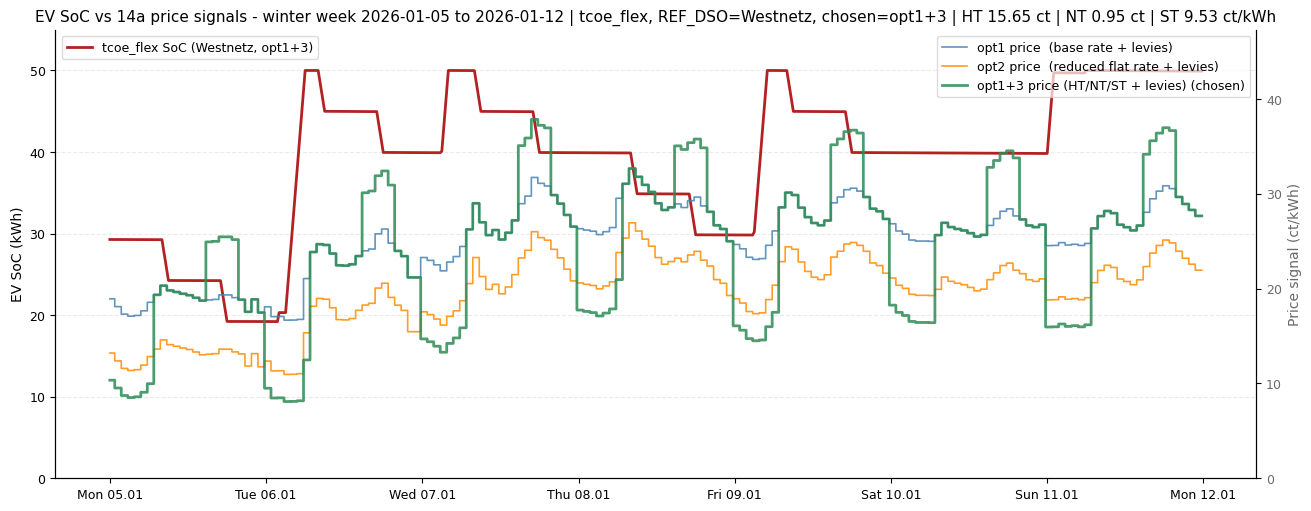

In [6]:
REF_DSO = 'Westnetz' if 'Westnetz' in schedules['tcoe_flex'] else next(iter(schedules['tcoe_flex']))
opt_tc  = schedules['tcoe_flex'][REF_DSO][3]
Eev_tc  = np.asarray(schedules['tcoe_flex'][REF_DSO][2], dtype=float)

# Reconstruct SoC for visualisation
soc_tc_vis = soc_tc[REF_DSO]     # from QA step above
soc_nf_vis = soc_nf              # from no_flex simulation

# Build all three 14a price signals for REF_DSO
dso_ref  = dso_tariffs.loc[dso_tariffs['DSO'] == REF_DSO].iloc[0]
base_ap  = float(dso_ref['Arbeitspreis_ct_kWh'])
mod2_ct  = float(dso_ref['Module2_ct_kWh'])
ev_mod3  = build_ev_dso_rate_mod3(df['timestamp'], REF_DSO, dso_ref)

c_opt1   = spot_arr + base_ap + TAX_PRE_VAT
c_opt2   = spot_arr + mod2_ct  + TAX_PRE_VAT
c_opt13  = spot_arr + ev_mod3  + TAX_PRE_VAT

# Winter week: first week where EV demand is in top 10% (cold, lots of driving + charging)
ev_daily = pd.Series(E_dem, index=pd.to_datetime(df['timestamp'])).resample('D').sum()
win_start = pd.Timestamp(
    ev_daily[ev_daily >= ev_daily.quantile(0.90)].index[0]
).floor('D')
while win_start.weekday() != 0:
    win_start += pd.Timedelta(days=1)
win_end = win_start + pd.Timedelta(days=7)
mask    = ((df['timestamp'] >= win_start) & (df['timestamp'] < win_end)).values
x       = pd.to_datetime(df.loc[mask, 'timestamp'])

soc_tc_plot = soc_tc_vis[:-1][mask]
soc_nf_plot = soc_nf_vis[:-1][mask]

fig, ax_soc = plt.subplots(1, 1, figsize=(13, 5), constrained_layout=True)

ax_pr = ax_soc.twinx()
ax_pr.step(x, c_opt1[mask],  where='pre', lw=1.2, color='steelblue',  alpha=0.85,
           label='opt1 price  (base rate + levies)')
ax_pr.step(x, c_opt2[mask],  where='pre', lw=1.2, color='darkorange', alpha=0.85,
           label='opt2 price  (reduced flat rate + levies)')
lw_13 = 2.0 if opt_tc == 'opt1+3' else 1.2
ax_pr.step(x, c_opt13[mask], where='pre', lw=lw_13, color='seagreen', alpha=0.85,
           label=f'opt1+3 price (HT/NT/ST + levies){" (chosen)" if opt_tc == "opt1+3" else ""}')
ax_pr.set_ylabel('Price signal (ct/kWh)', color='dimgrey')
ax_pr.tick_params(axis='y', labelcolor='dimgrey', labelsize=9)
ax_pr.set_ylim(0, max(c_opt1[mask].max(), c_opt13[mask].max()) * 1.25)
ax_pr.legend(loc='upper right', framealpha=0.7)
ax_pr.spines['top'].set_visible(False)

ax_soc.plot(x, soc_tc_plot,  lw=2.0, color='firebrick', label=f'tcoe_flex SoC ({REF_DSO}, {opt_tc})')
ax_soc.set_ylabel('EV SoC (kWh)')
ax_soc.set_ylim(0, E_EV_max * 1.1)
ax_soc.legend(loc='upper left', framealpha=0.7)
ax_soc.grid(axis='y', linestyle='--', alpha=0.25)
ax_soc.spines[['top']].set_visible(False)

ax_soc.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m'))
ax_soc.xaxis.set_major_locator(mdates.DayLocator())

ax_soc.set_title(
    f'EV SoC vs 14a price signals - winter week {win_start.date()} to {win_end.date()} | '
    f'tcoe_flex, REF_DSO={REF_DSO}, chosen={opt_tc} | '
    f'HT {dso_ref["HT_ct_kWh"]} ct | NT {dso_ref["NT_ct_kWh"]} ct | ST {dso_ref["ST_ct_kWh"]} ct/kWh'
)
plt.show()


## Step 6 — Billing

**§14a billing options per strategy:**
- `no_flex` / `dt_flex`: billed under **opt1** (EV at base DSO rate + Module 1 annual rebate)
- `tcoe_flex`: billed under the **winning option** from the LP sweep per DSO

Module 1 rebate (`Module1_rebate_EUR_year`) is a negative annual EUR credit (discount), included in the DSO volumetric component before VAT.


In [7]:
results = []
for _, dso_row in dso_tariffs.iterrows():
    dso_id = str(dso_row['DSO'])
    for strategy in ('no_flex', 'dt_flex', 'tcoe_flex'):
        if strategy == 'tcoe_flex':
            _val = schedules['tcoe_flex'][dso_id]
            E_g, E_ev = np.asarray(_val[0]), np.asarray(_val[2])
            opt = _val[3]
        else:
            E_g, _, E_ev = schedules[strategy]
            E_g, E_ev = np.asarray(E_g), np.asarray(E_ev)
            opt = 'opt1'

        base_ap  = float(dso_row['Arbeitspreis_ct_kWh'])
        mod1_eur = float(dso_row['Module1_rebate_EUR_year'])
        mod2_ct  = float(dso_row['Module2_ct_kWh'])

        cost_spot = np.sum((q_base + E_ev) * spot_arr) / 100.0
        if opt == 'opt1':
            cost_dso_vol = np.sum((q_base + E_ev) * base_ap) / 100.0 + mod1_eur
            cost_mod1    = mod1_eur
        elif opt == 'opt2':
            cost_dso_vol = (np.sum(q_base * base_ap) + np.sum(E_ev * mod2_ct)) / 100.0
            cost_mod1    = 0.0
        else:
            ev_r = build_ev_dso_rate_mod3(df['timestamp'], dso_id, dso_row)
            cost_dso_vol = np.sum(q_base * base_ap) / 100.0 + np.sum(E_ev * ev_r) / 100.0 + mod1_eur
            cost_mod1    = mod1_eur

        cost_lev   = np.sum(q_base + E_ev) * TAX_PRE_VAT / 100.0
        cost_fixed = float(dso_row['Grundpreis_EUR_year'])
        subtotal   = cost_spot + cost_dso_vol + cost_lev + cost_fixed + SMART_OP_EUR
        vat        = VAT_RATE * subtotal

        results.append({
            'strategy'                     : strategy,
            'household_archetype'          : 5,
            'dso_id'                       : dso_id,
            'annual_energy_kwh'            : round(float(np.sum(q_base + E_ev)), 2),
            'cost_spot_net_eur'            : round(cost_spot,  2),
            'cost_dso_volumetric_net_eur'  : round(cost_dso_vol, 2),
            'cost_dso_fixed_net_eur'       : round(cost_fixed, 2),
            'cost_smart_operating_net_eur' : round(SMART_OP_EUR, 2),
            'cost_14a_mod1_net_eur'        : round(cost_mod1, 2),
            'cost_levies_pre_vat_eur'      : round(cost_lev,  2),
            'subtotal_net_eur'             : round(subtotal,  2),
            'vat_eur'                      : round(vat,       2),
            'total_tcoe_eur'               : round(subtotal + vat, 2),
            'billing_14a_option'           : opt,
            'optimized_14a_option'         : opt if strategy == 'tcoe_flex' else None,
        })

results = pd.DataFrame(results)
assert results['total_tcoe_eur'].notna().all(), 'NaN in total_tcoe_eur'
print(f'TCoE range (all 21 runs): {results["total_tcoe_eur"].min():.2f} – {results["total_tcoe_eur"].max():.2f} EUR/year')
print(f'Winning §14a options (tcoe_flex): {results[results["strategy"]=="tcoe_flex"]["billing_14a_option"].value_counts().to_dict()}')
results


TCoE range (all 21 runs): 1665.31 – 2563.05 EUR/year
Winning §14a options (tcoe_flex): {'opt1+3': 7}


,strategy,household_archetype,dso_id,annual_energy_kwh,cost_spot_net_eur,cost_dso_volumetric_net_eur,cost_dso_fixed_net_eur,cost_smart_operating_net_eur,cost_14a_mod1_net_eur,cost_levies_pre_vat_eur,subtotal_net_eur,vat_eur,total_tcoe_eur,billing_14a_option,optimized_14a_option
0,no_flex,5,Westnetz,7769.42,855.91,601.73,80.30,100.0,-138.70,515.89,2153.83,409.23,2563.05,opt1,None
1,dt_flex,5,Westnetz,7792.45,486.94,603.92,80.30,100.0,-138.70,517.42,1788.58,339.83,2128.41,opt1,None
2,tcoe_flex,5,Westnetz,7761.66,536.81,360.96,80.30,100.0,-138.70,515.37,1593.45,302.75,1896.20,opt1+3,opt1+3
3,no_flex,5,Bayernwerk,7769.42,855.91,243.54,98.55,100.0,-123.18,515.89,1813.89,344.64,2158.53,opt1,None
4,dt_flex,5,Bayernwerk,7792.45,486.94,244.62,98.55,100.0,-123.18,517.42,1447.53,275.03,1722.57,opt1,None
5,tcoe_flex,5,Bayernwerk,7761.59,489.15,196.36,98.55,100.0,-123.18,515.37,1399.42,265.89,1665.31,opt1+3,opt1+3
6,no_flex,5,E.DIS,7769.42,855.91,316.74,76.65,100.0,-108.25,515.89,1865.19,354.39,2219.57,opt1,None
7,dt_flex,5,E.DIS,7792.45,486.94,318.00,76.65,100.0,-108.25,517.42,1499.01,284.81,1783.82,opt1,None
8,tcoe_flex,5,E.DIS,7761.21,493.50,240.61,76.65,100.0,-108.25,515.34,1426.11,270.96,1697.07,opt1+3,opt1+3
9,no_flex,5,Netze BW,7769.42,855.91,407.36,84.00,100.0,-180.78,515.89,1963.17,373.00,2336.17,opt1,None


## Step 7 — Summary and export

In [8]:
# ── Table 1: no_flex cost breakdown (reference — comparable to Archetypes 1–4) ────
nf = (results[results['strategy'] == 'no_flex']
      [['dso_id', 'cost_spot_net_eur', 'cost_dso_volumetric_net_eur',
        'cost_14a_mod1_net_eur', 'cost_dso_fixed_net_eur',
        'cost_smart_operating_net_eur', 'cost_levies_pre_vat_eur',
        'vat_eur', 'total_tcoe_eur']]
      .set_index('dso_id')
      .rename(columns={
          'cost_spot_net_eur'               : 'Spot net (€)',
          'cost_dso_volumetric_net_eur'     : 'DSO vol (€)',
          'cost_14a_mod1_net_eur'           : '§14a Mod1 rebate (€)',
          'cost_dso_fixed_net_eur'          : 'DSO fix (€)',
          'cost_smart_operating_net_eur'    : 'Smart op. (€)',
          'cost_levies_pre_vat_eur'         : 'Levies pre-VAT (€)',
          'vat_eur'                         : 'VAT (€)',
          'total_tcoe_eur'                  : 'TCoE no_flex (€/yr)',
      }))

print(f'Annual grid draw (no_flex): {E_grid_nf.sum():.2f} kWh  '
      f'(base {q_base.sum():.1f} kWh  |  EV {E_ev_nf.sum():.1f} kWh)')
print('\nTable 1 — no_flex cost breakdown (reference, §14a opt1):')
display(nf)

# ── Table 2: strategy comparison + flex savings ────────────────────────────────
piv = results.pivot_table(index='dso_id', columns='strategy',
                           values='total_tcoe_eur', aggfunc='first')
piv = piv[['no_flex', 'dt_flex', 'tcoe_flex']]
piv.columns.name = None
piv['saving dt_flex (€/yr)']   = piv['no_flex'] - piv['dt_flex']
piv['saving tcoe_flex (€/yr)'] = piv['no_flex'] - piv['tcoe_flex']
piv = piv.rename(columns={
    'no_flex'   : 'TCoE no_flex (€/yr)',
    'dt_flex'   : 'TCoE dt_flex (€/yr)',
    'tcoe_flex' : 'TCoE tcoe_flex (€/yr)',
})
print('\nTable 2 — strategy comparison and flex savings vs no_flex:')
display(piv)

out = OUTPUTS / 'results_base_ev_2026.csv'
results.to_csv(out, index=False)
print(f'\nSaved : {out}')
print(f'Rows  : {len(results)}  (3 strategies x 7 DSOs)')


Annual grid draw (no_flex): 7769.42 kWh  (base 4500.0 kWh  |  EV 3269.4 kWh)

Table 1 — no_flex cost breakdown (reference, §14a opt1):


,Spot net (€),DSO vol (€),§14a Mod1 rebate (€),DSO fix (€),Smart op. (€),Levies pre-VAT (€),VAT (€),TCoE no_flex (€/yr)
dso_id,,,,,,,,
Westnetz,855.91,601.73,-138.70,80.30,100.0,515.89,409.23,2563.05
Bayernwerk,855.91,243.54,-123.18,98.55,100.0,515.89,344.64,2158.53
E.DIS,855.91,316.74,-108.25,76.65,100.0,515.89,354.39,2219.57
Netze BW,855.91,407.36,-180.78,84.00,100.0,515.89,373.00,2336.17
Stromnetz Berlin,855.91,456.42,-123.18,33.36,100.0,515.89,372.70,2334.28
SH Netz,855.91,382.01,-115.23,94.90,100.0,515.89,370.26,2318.97
MITNETZ STROM,855.91,375.70,-114.55,73.00,100.0,515.89,364.90,2285.40



Table 2 — strategy comparison and flex savings vs no_flex:


,TCoE no_flex (€/yr),TCoE dt_flex (€/yr),TCoE tcoe_flex (€/yr),saving dt_flex (€/yr),saving tcoe_flex (€/yr)
dso_id,,,,,
Bayernwerk,2158.53,1722.57,1665.31,435.96,493.22
E.DIS,2219.57,1783.82,1697.07,435.75,522.50
MITNETZ STROM,2285.40,1849.87,1757.34,435.53,528.06
Netze BW,2336.17,1900.99,1808.17,435.18,528.00
SH Netz,2318.97,1883.47,1739.74,435.50,579.23
Stromnetz Berlin,2334.28,1899.07,1776.32,435.21,557.96
Westnetz,2563.05,2128.41,1896.20,434.64,666.85



Saved : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/outputs/results_base_ev_2026.csv
Rows  : 21  (3 strategies x 7 DSOs)
